# SEC XBRL Fundamentals

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`

This notebook analyzes quarterly fundamental data fetched by the canonical
downloader `data/equities/fundamentals/xbrl_download.py` from the SEC EDGAR XBRL
Frames API, for use in downstream factor engineering (Chapter 6).

## Why Direct API vs edgartools?

The `02_sec_filing_explorer.py` notebook demonstrates using the edgartools library for
**individual company analysis**: exploring filings, extracting financial statements,
and parsing 13F holdings. edgartools is excellent for deep dives into specific companies.

This notebook takes a different approach: **bulk data retrieval** using the SEC's
XBRL Frames API, which provides aggregated data across all filers in a single request.
This is more efficient for building cross-sectional fundamental datasets.

| Use Case | Best Tool |
|----------|-----------|
| Analyze a single company's filings | `02_sec_filing_explorer.py` |
| Build factor dataset for 20+ stocks | This notebook (XBRL Frames API) |
| Parse complex filing documents | `02_sec_filing_explorer.py` |
| Get quarterly aggregates across market | This notebook (XBRL Frames API) |

## Point-in-Time (PIT) Correctness

**Critical**: Fundamental data for backtesting must reflect only information
available at each historical date. Using fiscal quarter end dates causes
look-ahead bias because filings are released 30-60 days later.

The downloader joins **filing dates** from the SEC Submissions API onto the
XBRL frames so each row carries both `fiscal_quarter_end` (valid time) and
`announcement_date` (knowledge time):

| Date Type | Usage |
|-----------|-------|
| `fiscal_quarter_end` | Period the data describes (e.g., 2024-03-31) |
| `announcement_date` | When SEC filing was submitted (e.g., 2024-05-02) |

For backtesting, use `announcement_date` as the point when data becomes available.

## Data Sources

The downloader uses two free, public SEC EDGAR APIs (no vendor subscription):

1. **XBRL Frames API** — aggregated financial data across all filers:
   `https://data.sec.gov/api/xbrl/frames/{taxonomy}/{concept}/{unit}/{period}.json`

   **CY vs FY Frames**: The API uses **CY** (calendar year) quarters, not fiscal year.
   This is intentional: CY frames provide cross-sectional snapshots where all companies
   report the same calendar period, enabling apples-to-apples comparisons.
   Companies with non-calendar fiscal years (e.g., MSFT ends June 30) have their
   data mapped to the appropriate CY quarter.

2. **Submissions API** — per-company filing metadata cached per CIK on first
   fetch so re-runs do not re-hit the endpoint:
   `https://data.sec.gov/submissions/CIK{cik}.json`

## Downloader

```bash
# 20 large-cap US equities × 2022-2024 × 11 standard concepts (~2-3 min)
uv run python data/equities/fundamentals/xbrl_download.py

# Custom year range or CIK list
uv run python data/equities/fundamentals/xbrl_download.py --years 2020,2021,2022,2023,2024
uv run python data/equities/fundamentals/xbrl_download.py --ciks 320193
```

The loader raises `DataNotFoundError` with the exact command if the parquet
is missing — no hidden HTTP calls inside the notebook.

## Cross-Reference

- **Related**: `02_sec_filing_explorer.py` (individual company SEC filings)
- **Downstream**: Chapter 8 `04_fundamentals_macro_calendar.py` (factor engineering)

In [1]:
"""SEC XBRL Fundamentals — analyze quarterly fundamentals from the canonical xbrl_download.py output."""

import plotly.graph_objects as go
import polars as pl

from data import load_sec_xbrl_fundamentals

# Importing utils.style registers and activates the ML4T Plotly template
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all

## 1. Load the Fundamentals Panel

The canonical downloader ships a default universe of 20 large-cap US equities
across 2022-2024 with 11 standard us-gaap concepts. Here we load the full panel
and inspect the schema.

In [3]:
fundamentals = load_sec_xbrl_fundamentals()

print(f"Rows:     {len(fundamentals):,}")
print(f"CIKs:     {fundamentals.select('cik').n_unique()}")
print(f"Symbols:  {fundamentals.select('symbol').n_unique()}")
print(f"Quarters: {fundamentals.select('fiscal_quarter_end').n_unique()}")
print(f"Columns:  {fundamentals.columns}")

Rows:     240
CIKs:     20
Symbols:  20
Quarters: 49
Columns:  ['symbol', 'cik', 'entity_name', 'fiscal_quarter_end', 'announcement_date', 'accession', 'assets', 'cashandcashequivalentsatcarryingvalue', 'grossprofit', 'liabilities', 'longtermdebt', 'netcashprovidedbyusedinoperatingactivities', 'netincomeloss', 'operatingincomeloss', 'paymentstoacquirepropertyplantandequipment', 'revenues', 'stockholdersequity']


Balance-sheet sample (8 rows):

In [4]:
balance_cols = [
    c
    for c in [
        "symbol",
        "entity_name",
        "fiscal_quarter_end",
        "announcement_date",
        "assets",
        "liabilities",
        "stockholdersequity",
    ]
    if c in fundamentals.columns
]
fundamentals.select(balance_cols).head(8)

symbol,entity_name,fiscal_quarter_end,announcement_date,assets,liabilities,stockholdersequity
str,str,date,date,i64,i64,i64
"""AAPL""","""Apple Inc.""",2022-03-26,2022-04-29,350662000000,283263000000,67399000000
"""AAPL""","""Apple Inc.""",2022-06-25,2022-07-29,336309000000,278202000000,58107000000
"""AAPL""","""Apple Inc.""",2022-09-24,2023-11-03,352755000000,302083000000,50672000000
"""AAPL""","""Apple Inc.""",2022-12-31,2023-02-03,346747000000,290020000000,56727000000
"""AAPL""","""Apple Inc.""",2023-04-01,2023-05-05,332160000000,270002000000,62158000000
"""AAPL""","""Apple Inc.""",2023-07-01,2023-08-04,335038000000,274764000000,60274000000
"""AAPL""","""Apple Inc.""",2023-09-30,2024-11-01,352583000000,290437000000,62146000000
"""AAPL""","""Apple Inc.""",2023-12-30,2024-02-02,353514000000,279414000000,74100000000


Income + cash-flow sample (8 rows). `revenues` is sparse here because Apple and several
other large filers report under the post-ASC-606 concept
`RevenueFromContractWithCustomerExcludingAssessedTax`, which the canonical downloader
pulls into a separate column rather than filling `revenues`.

In [5]:
flow_cols = [
    c
    for c in [
        "symbol",
        "fiscal_quarter_end",
        "announcement_date",
        "revenues",
        "netincomeloss",
        "netcashprovidedbyusedinoperatingactivities",
    ]
    if c in fundamentals.columns
]
fundamentals.select(flow_cols).head(8)

symbol,fiscal_quarter_end,announcement_date,revenues,netincomeloss,netcashprovidedbyusedinoperatingactivities
str,date,date,i64,i64,i64
"""AAPL""",2022-03-26,2022-04-29,null,25010000000,null
"""AAPL""",2022-06-25,2022-07-29,null,19442000000,null
"""AAPL""",2022-09-24,2023-11-03,null,null,null
"""AAPL""",2022-12-31,2023-02-03,null,29998000000,34005000000
"""AAPL""",2023-04-01,2023-05-05,null,24160000000,null
"""AAPL""",2023-07-01,2023-08-04,null,19881000000,null
"""AAPL""",2023-09-30,2024-11-01,null,null,null
"""AAPL""",2023-12-30,2024-02-02,null,33916000000,39895000000


## 2. Data Coverage

Not every concept is reported by every company every quarter. Banks and
some post-ASC-606 filers (e.g. AAPL, MSFT) report revenue under other
concepts like `RevenueFromContractWithCustomerExcludingAssessedTax`
rather than `Revenues`. Visualize coverage to understand the gaps before
using this data downstream.

In [6]:
coverage_df = (
    fundamentals.with_columns(
        (
            pl.col("fiscal_quarter_end").dt.year().cast(pl.Utf8)
            + "Q"
            + ((pl.col("fiscal_quarter_end").dt.month() - 1) // 3 + 1).cast(pl.Utf8)
        ).alias("quarter")
    )
    .group_by(["symbol", "quarter"])
    .agg(
        pl.col("assets").is_not_null().sum().alias("assets_available"),
    )
)

coverage_pivot = coverage_df.pivot(
    on="quarter", index="symbol", values="assets_available"
).fill_null(0)

symbols = coverage_pivot["symbol"].to_list()
quarters = sorted([c for c in coverage_pivot.columns if c != "symbol"])

matrix = []
for symbol in symbols:
    row = coverage_pivot.filter(pl.col("symbol") == symbol)
    values = [int(row[q].item()) if q in row.columns else 0 for q in quarters]
    matrix.append(values)

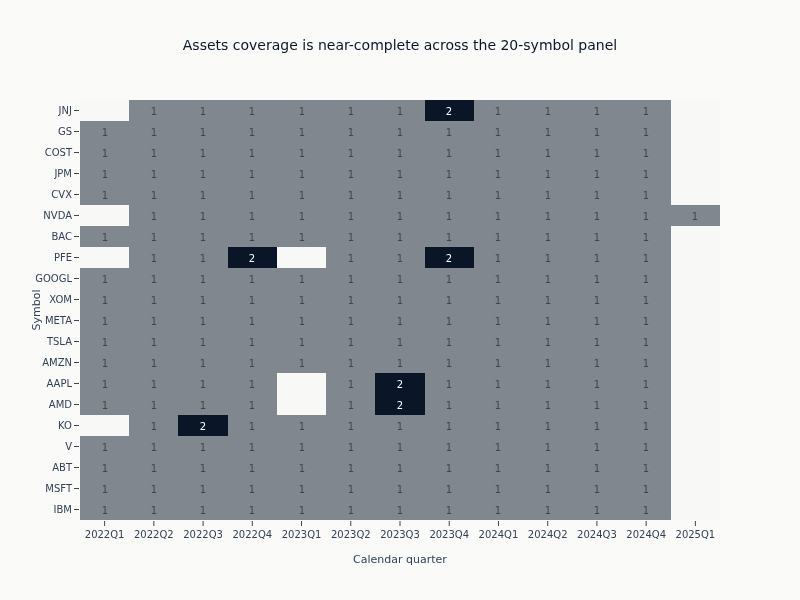

`assets` coverage: 234/260 (90.0%)


In [7]:
fig = go.Figure(
    data=go.Heatmap(
        z=matrix,
        x=quarters,
        y=symbols,
        colorscale=[[0, COLORS["silver"]], [1, COLORS["blue"]]],
        showscale=False,
        text=[[str(v) if v > 0 else "" for v in row] for row in matrix],
        texttemplate="%{text}",
        textfont={"size": 10},
    )
)
fig.update_layout(
    title="Assets coverage is near-complete across the 20-symbol panel",
    xaxis_title="Calendar quarter",
    yaxis_title="Symbol",
    height=600,
    width=800,
)
fig.show()

total_cells = len(symbols) * len(quarters)
# Count symbol-quarter CELLS that carry at least one assets value, not the number of
# filings: six cells hold two rows (an original plus an amended/restated filing that maps
# to the same calendar quarter, the "2" cells above), and summing the counts would credit
# those as extra coverage.
filled_cells = sum(1 for row in matrix for v in row if v > 0)
print(f"`assets` coverage: {filled_cells}/{total_cells} ({100 * filled_cells / total_cells:.1f}%)")

## 3. Filing-Lag Statistics

The gap between `fiscal_quarter_end` and `announcement_date` is the
window during which a company's fundamentals are unknown to the market
— critical for any PIT backtest.

In [8]:
filing_lag = (
    fundamentals.filter(pl.col("announcement_date").is_not_null())
    .with_columns(
        (pl.col("announcement_date") - pl.col("fiscal_quarter_end"))
        .dt.total_days()
        .alias("lag_days")
    )
    .select(["symbol", "fiscal_quarter_end", "lag_days"])
)

filing_lag.select("lag_days").describe()

statistic,lag_days
str,f64
"""count""",204.0
"""null_count""",0.0
"""mean""",149.191176
"""std""",192.045607
"""min""",19.0
"""25%""",27.0
"""50%""",33.0
"""75%""",395.0
"""max""",781.0


The median filing lag (~33 days) reflects typical 10-Q timing. The elevated mean
and long tail arise from amended/restated filings — the XBRL Frames API may return
accession numbers for restated filings rather than original submissions. For PIT
backtesting, this is conservative (data appears later than reality).

The distribution makes the two regimes visible: a tall cluster near one month
(routine 10-Q filings) and a sparse tail of restatements reaching past a year.

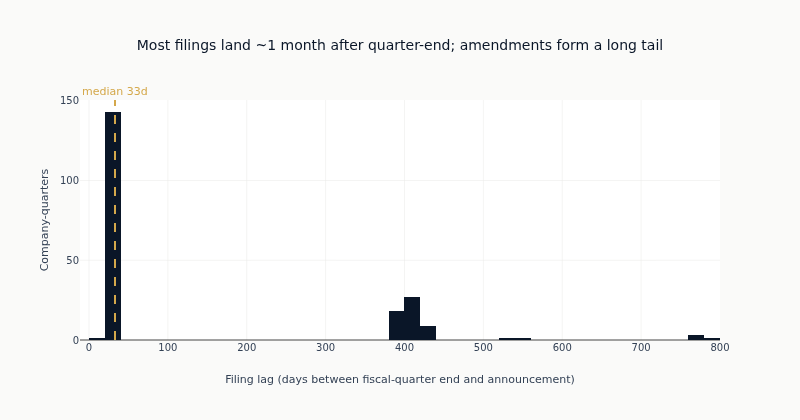

In [9]:
lags = filing_lag["lag_days"].to_list()
median_lag = filing_lag["lag_days"].median()

fig = go.Figure(
    data=go.Histogram(
        x=lags,
        xbins={"start": 0, "end": 800, "size": 20},
        marker_color=COLORS["blue"],
    )
)
fig.add_vline(
    x=median_lag,
    line_dash="dash",
    line_color=COLORS["amber"],
    annotation_text=f"median {median_lag:.0f}d",
    annotation_position="top",
    annotation_font_color=COLORS["amber"],
)
fig.update_layout(
    title="Most filings land ~1 month after quarter-end; amendments form a long tail",
    xaxis_title="Filing lag (days between fiscal-quarter end and announcement)",
    yaxis_title="Company-quarters",
    height=420,
    width=800,
)
fig.show()

## 4. Bitemporal Query Patterns

The fundamentals panel has two time dimensions:
- `fiscal_quarter_end`: the period the data describes (*valid time*)
- `announcement_date`: when the SEC filing was submitted (*knowledge time*)

For backtesting, use `announcement_date` to avoid lookahead bias. The
**as-of query** pattern returns only data that was publicly available on
a given date.

The two dimensions do two different jobs, and it is worth being precise about which
does what. `announcement_date` decides *admissibility*: a row is usable only if the
market already knew it. `fiscal_quarter_end` decides *recency*: among the rows that
pass, the one describing the most recent period is the one you want. Sorting by
`announcement_date` and taking the last row conflates the two — it returns the
most-recently-*announced* row, which is not the freshest quarter whenever an old
quarter is announced late. That is not a hypothetical here: the filing-lag tail above
(p75 = 395 days) is exactly this, because the Frames API attributes fiscal-Q4 facts to
the next year's 10-K. Sort by `fiscal_quarter_end`, filter on `announcement_date`.

In [10]:
def query_fundamentals_as_of(df: pl.DataFrame, as_of_date: str) -> pl.DataFrame:
    """Return latest known fundamentals as of a specific date (PIT-correct).

    Admissibility is set by `announcement_date` (what the market knew); recency is set
    by `fiscal_quarter_end` (which period the fact describes).
    """
    query_date = pl.lit(as_of_date).str.to_date()
    return (
        df.filter(pl.col("announcement_date") <= query_date)
        .sort(["symbol", "fiscal_quarter_end"])
        .group_by("symbol")
        .last()
    )

A row with no `announcement_date` has no knowledge time, so it can never be shown to
be admissible and the filter drops it. That is the right call, but a silent one: the
coverage it costs is worth stating out loud before relying on the panel.

In [11]:
n_null = fundamentals["announcement_date"].is_null().sum()
print(
    f"Rows with no announcement_date: {n_null} of {fundamentals.height} "
    f"({n_null / fundamentals.height:.1%}) — never admissible to a PIT query."
)

Rows with no announcement_date: 36 of 240 (15.0%) — never admissible to a PIT query.


### Demonstration: Correct vs Incorrect Queries

Both queries below run on the rows that carry a knowledge time. Restricting the
comparison to a single universe is what makes it a clean read on lookahead bias: if
the correct query dropped the null-`announcement_date` rows and the lookahead one kept
them, the mismatch count would mix the coverage gap into the answer.

In [12]:
pit_panel = fundamentals.filter(pl.col("announcement_date").is_not_null())
as_of_date = "2023-06-30"
print(f"As of {as_of_date}, the latest quarter known to the market for each symbol:")

As of 2023-06-30, the latest quarter known to the market for each symbol:


**Correct** — filter on `announcement_date <= as_of`:

In [13]:
known_correct = query_fundamentals_as_of(pit_panel, as_of_date)
cols = [
    c
    for c in ["symbol", "fiscal_quarter_end", "announcement_date", "netincomeloss"]
    if c in known_correct.columns
]
known_correct.select(cols).head(5)

symbol,fiscal_quarter_end,announcement_date,netincomeloss
str,date,date,i64
"""AAPL""",2023-04-01,2023-05-05,24160000000
"""ABT""",2023-03-31,2023-05-04,1318000000
"""AMD""",2023-04-01,2023-05-03,-139000000
"""AMZN""",2023-03-31,2023-04-28,3172000000
"""COST""",2023-03-31,2023-05-01,4228000000


**Lookahead-biased** — filter on `fiscal_quarter_end <= as_of`. This includes
quarters whose filings hadn't been submitted yet on the as-of date:

In [14]:
query_date = pl.lit(as_of_date).str.to_date()
known_wrong = (
    pit_panel.filter(pl.col("fiscal_quarter_end") <= query_date)
    .sort(["symbol", "fiscal_quarter_end"])
    .group_by("symbol")
    .last()
)
known_wrong.select(cols).head(5)

symbol,fiscal_quarter_end,announcement_date,netincomeloss
str,date,date,i64
"""AAPL""",2023-04-01,2023-05-05,24160000000
"""ABT""",2023-06-30,2023-08-03,1375000000
"""AMD""",2023-04-01,2023-05-03,-139000000
"""AMZN""",2023-06-30,2023-08-04,6750000000
"""COST""",2023-06-30,2023-07-27,4489000000


Comparing the two — every row here is a symbol the lookahead-biased approach
would have used a fresher quarter than was actually available:

In [15]:
correct_dates = known_correct.select(["symbol", "fiscal_quarter_end"]).rename(
    {"fiscal_quarter_end": "correct_qtr"}
)
wrong_dates = known_wrong.select(["symbol", "fiscal_quarter_end"]).rename(
    {"fiscal_quarter_end": "wrong_qtr"}
)
mismatches = correct_dates.join(wrong_dates, on="symbol").filter(
    pl.col("correct_qtr") != pl.col("wrong_qtr")
)
print(f"{len(mismatches)} symbols where lookahead bias would change the chosen quarter:")
mismatches

11 symbols where lookahead bias would change the chosen quarter:


symbol,correct_qtr,wrong_qtr
str,date,date
"""ABT""",2023-03-31,2023-06-30
"""AMZN""",2023-03-31,2023-06-30
"""COST""",2023-03-31,2023-06-30
"""CVX""",2023-03-31,2023-06-30
"""GOOGL""",2023-03-31,2023-06-30
…,…,…
"""KO""",2023-03-31,2023-06-30
"""MSFT""",2023-03-31,2023-06-30
"""TSLA""",2023-03-31,2023-06-30


## Key Takeaways

1. The SEC XBRL Frames API is sufficient to assemble a cross-sectional fundamentals panel without a vendor subscription. The default downloader output covers 20 large-cap US equities × 49 quarters × 11 us-gaap concepts (240 rows in this snapshot).
2. Coverage is concept-dependent. `assets` fills 90.0% of company × quarter cells in this universe (234 of 260); `revenues` is sparse for AAPL/MSFT/banks because they file under post-ASC-606 concepts.
3. Filing-lag stats expose two regimes: the median filing lands ~33 days after fiscal-quarter end (typical 10-Q timing), but the upper quartile starts at 395 days and the max reaches 781 days — that long tail is dominated by amended/restated filings returned by the XBRL Frames API.
4. Always filter on `announcement_date` for backtesting, and sort by `fiscal_quarter_end` to pick the winner. Filtering on the wrong column injects lookahead bias: querying as of 2023-06-30 by `fiscal_quarter_end` picks a fresher quarter than was available for 11 of the 16 symbols with admissible data — Q2 2023 fundamentals that were not filed until August 2023. Sorting on the wrong column is the subtler error: `announcement_date` selects the most-recently-announced row, which walks *backwards* in fiscal time whenever a restatement or a late-attributed Q4 fact lands, so the "PIT-correct" query would return a stale quarter right after every 10-K.
5. Knowledge time can be missing: 36 of 240 rows (15%) carry no `announcement_date` and are therefore never admissible to a PIT query. Report that coverage gap rather than letting the filter drop it silently.
6. The downloader and loader are the production interface; this notebook is a sanity-check + bitemporal-query template that downstream feature-engineering notebooks (Ch8) consume.